# AAPL Triple-Barrier Forecasting

Reference-anchored stock-direction forecasting on AAPL daily bars (2010-2024).
Built against AFML (López de Prado), Goodfellow et al. Ch.10, and Jansen Ch.19.

**This notebook supersedes** `archive/notebooks/DataSynthis_ML_JobTask_original.ipynb`.

## Why this pipeline (vs the original)

The original notebook trained an LSTM to predict next-day log return (MSE loss) on a single chronological train/val/test split. Result: LSTM directional accuracy 51.25% on 499 test days — not statistically distinguishable from 50% (binomial p > 0.2). Diagnosis: the model collapsed to predicting the unconditional mean because:

| Issue | Reference for the fix |
|---|---|
| Fixed-time-horizon labeling | AFML Ch.3 Snippets 3.2–3.5 (BonusPDF pp.27–30) — **triple-barrier method** |
| Integer differentiation destroys memory | AFML Ch.5 §5.4 (BonusPDF p.46) — **fractional differentiation** |
| Single chronological split leaks via lookbacks | AFML Ch.7 Snippets 7.1–7.3 (BonusPDF pp.63–66) — **PurgedKFold + embargo** |
| No gradient clipping on 60-step BPTT | Goodfellow §10.11.1 eq 10.48–49 (PDF p.414) — **clipnorm=1.0** |
| Loss (MSE) misaligned with metric (direction) | Goodfellow §11.1 (PDF p.422) — **categorical_crossentropy** |
| 128/64-unit model on ~2700 unique training samples | Jansen Ch.19 NB 01 uses 10 units; Karpathy generalization caveat |

The label set is now `{-1, 0, +1}` from the triple-barrier method; the metric is accuracy (binomial null = 1/3) and *directional accuracy when acting* (null = 1/2, only over predictions ≠ 0).

---
## 1. Setup & data load

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make `src` importable when the notebook is launched from `notebooks/`
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_aapl_with_spy, get_daily_vol
from src.features import frac_diff_ffd, find_min_d, get_ffd_weights, rolling_zscore
from src.labeling import cusum_filter, add_vertical_barrier, get_events, get_bins, drop_labels
from src.cv import PurgedKFold, binomial_pvalue
from src.eval import fold_metrics, summarize_results, confusion_table
from src.train import run_cv, uniqueness_weights

np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

df = load_aapl_with_spy()
print(f"Loaded {len(df)} rows | {df.index.min().date()} → {df.index.max().date()}")
df.head(3)

Loaded 3772 rows | 2010-01-05 → 2024-12-30


,Open,High,Low,Close,Adj Close,Volume,SPY_Close,SPY_Volume
Date,,,,,,,,
2010-01-05,7.6643,7.6996,7.6161,7.6564,6.4357,601904800,85.5050,111579900
2010-01-06,7.6564,7.6868,7.5268,7.5346,6.3333,552160000,85.5651,116074400
2010-01-07,7.5625,7.5714,7.4661,7.5207,6.3216,477131200,85.9263,131091100


## 2. EDA — just enough to verify the data

The original notebook had ~30 plots. Here we keep three: price, daily-return distribution, and a rolling-volatility chart. Everything else is downstream of the pipeline.

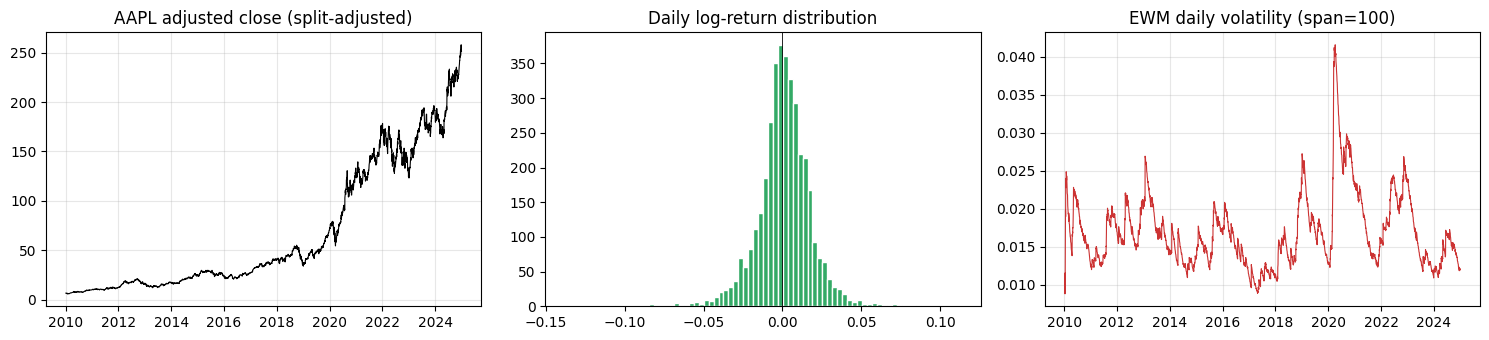

Mean daily return: 0.00097 (24.49% annualized)
Daily-return σ: 0.01756 (27.88% annualized)


In [2]:
close = df["Adj Close"]
log_returns = np.log(close).diff().dropna()
daily_vol = get_daily_vol(close, span=100)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(close.index, close.values, color="black", lw=0.8)
axes[0].set_title("AAPL adjusted close (split-adjusted)")
axes[0].grid(alpha=0.3)
axes[1].hist(log_returns, bins=80, color="#3a6", edgecolor="white")
axes[1].axvline(0, color="black", lw=0.6)
axes[1].set_title("Daily log-return distribution")
axes[2].plot(daily_vol.index, daily_vol.values, color="#c33", lw=0.8)
axes[2].set_title("EWM daily volatility (span=100)")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean daily return: {log_returns.mean():.5f} ({log_returns.mean()*252:.2%} annualized)")
print(f"Daily-return σ: {log_returns.std():.5f} ({log_returns.std()*np.sqrt(252):.2%} annualized)")

## 3. Event sampling — CUSUM filter

Rather than labeling every bar, we use a symmetric CUSUM filter to flag only timestamps where the cumulative return has accumulated past a threshold. This is AFML §2.5.2 — it produces an event-driven label set with much better statistical properties (the resulting events are closer to i.i.d. than evenly-spaced daily samples).

The threshold is set to the median EWM daily vol so that roughly one event per few trading days is generated.

In [3]:
cusum_threshold = float(daily_vol.median())
t_events = cusum_filter(np.log(close), threshold=cusum_threshold)
print(f"CUSUM threshold: {cusum_threshold:.5f}")
print(f"Event count: {len(t_events)} ({len(t_events)/len(close):.1%} of bars)")
print(f"Mean spacing: {(close.index[-1] - close.index[0]).days / len(t_events):.1f} calendar days per event")

CUSUM threshold: 0.01597
Event count: 1442 (38.2% of bars)
Mean spacing: 3.8 calendar days per event


## 4. Triple-barrier labels (AFML Snippets 3.2–3.5)

For each event we set three barriers:

- **Upper** = `+pt_mul × σ_event` (profit-taking)
- **Lower** = `-sl_mul × σ_event` (stop-loss)
- **Vertical** = `event + num_days` (max holding period)

`σ_event` is the EWM daily vol at the event time. The label is which barrier is hit first: `+1` (upper), `-1` (lower), or `0` (vertical, no signal). Barrier multipliers `pt_sl = (2, 2)` and `num_days = 5` are standard for daily bars per AFML.

In [4]:
events = get_events(
    close=close,
    t_events=t_events,
    pt_sl=(2.0, 2.0),
    target=daily_vol,
    min_ret=0.005,
    num_days=10,   # 10-day vertical barrier — gives ~balanced 3-class split on AAPL daily bars
)
labels = get_bins(events, close)
labels = labels.join(events["target"].rename("target_vol"))

# AFML Snippet 3.8 — drop labels with <5% support
events_with_labels = events.join(labels[["bin"]])
events_with_labels = drop_labels(events_with_labels, min_pct=0.05)
labels = labels.loc[events_with_labels.index]
events = events.loc[events_with_labels.index]

print(f"Final event count: {len(labels)}")
print("Label distribution (-1=stop-loss first, 0=time-out, +1=profit-taking first):")
print((labels["bin"].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")

# Show a sample of the events for sanity
print("\nFirst 3 events:")
print(events[["t1", "vertical_t1", "barrier_hit", "target"]].head(3))

Final event count: 1440
Label distribution (-1=stop-loss first, 0=time-out, +1=profit-taking first):
bin
-1    26.39%
 0     36.6%
 1    37.01%
Name: proportion, dtype: str

First 3 events:
                   t1 vertical_t1 barrier_hit  target
2010-01-12 2010-01-19  2010-01-22          pt  0.0088
2010-01-15 2010-01-19  2010-01-25          pt  0.0109
2010-01-19 2010-01-22  2010-01-29          sl  0.0198


## 5. Fractional differentiation (AFML Ch.5 §5.4)

Log-returns achieve stationarity but destroy all price memory beyond 1 lag. The original notebook gave up on price levels entirely for this reason. Fractional differentiation with `d ∈ (0, 1)` lets us preserve a long power-law tail of past prices *while* passing the ADF stationarity test.

Procedure:
1. Sweep `d ∈ [0, 1]` in 11 steps, FFD-difference the log-price at each `d`, run ADF.
2. Pick the **minimum** `d` where the ADF statistic is below the 5% critical value (~-2.86).
3. Apply `frac_diff_ffd(log_close, d)` and `frac_diff_ffd(log_volume, d)` to get the two memory-preserving features.

        adf_stat  crit_95  corr_with_original
d                                            
0.0000   -0.5583  -2.8623              1.0000
0.1000   -0.7914  -2.8623              0.9994
0.2000   -1.3968  -2.8623              0.9963
0.3000   -2.5304  -2.8623              0.9870
0.4000   -4.6699  -2.8623              0.9609
0.5000   -8.6610  -2.8623              0.8897
0.6000  -15.4803  -2.8623              0.7204
0.7000  -24.5679  -2.8623              0.4520
0.8000  -32.8421  -2.8623              0.2108
0.9000  -38.8850  -2.8623              0.0918
1.0000  -44.2334  -2.8623              0.0080

Chosen d = 0.4


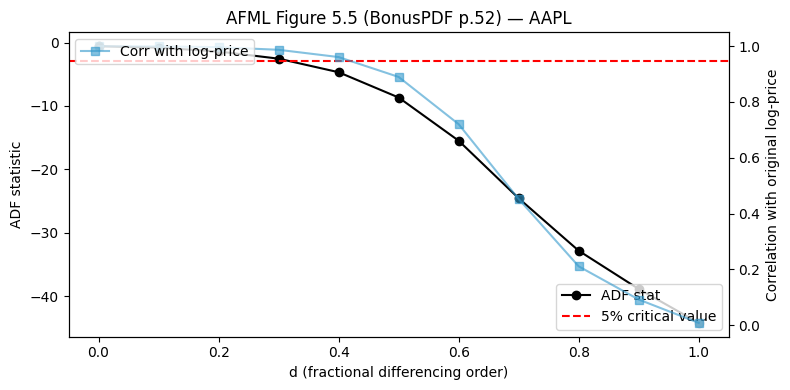

In [5]:
ffd_sweep = find_min_d(close.rename("close"), d_range=(0.0, 1.0), n_steps=11, thres=1e-5)
print(ffd_sweep[["adf_stat", "crit_95", "corr_with_original"]])

passing = ffd_sweep[ffd_sweep["adf_stat"] < ffd_sweep["crit_95"]]
min_d = float(passing.index.min()) if len(passing) else 0.5
print(f"\nChosen d = {min_d}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ffd_sweep.index, ffd_sweep["adf_stat"], "o-", label="ADF stat", color="black")
ax.axhline(ffd_sweep["crit_95"].mean(), ls="--", color="red", label="5% critical value")
ax.set_xlabel("d (fractional differencing order)")
ax.set_ylabel("ADF statistic")
ax2 = ax.twinx()
ax2.plot(ffd_sweep.index, ffd_sweep["corr_with_original"], "s-", color="#39c", alpha=0.6, label="Corr with log-price")
ax2.set_ylabel("Correlation with original log-price")
ax.set_title("AFML Figure 5.5 (BonusPDF p.52) — AAPL")
ax.legend(loc="lower right")
ax2.legend(loc="upper left")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "min_ffd_d.png", dpi=120)
plt.show()

## 6. Feature set

8 features, down from the original's 13. Eliminations:

- **Drop** `log_return`: subsumed by `frac_diff_close` (which preserves memory).
- **Drop** `return_lag2`, `return_lag5`: redundant with the LSTM's 60-day sequence window and with XGBoost's tree splits on `frac_diff_close`.
- **Drop** `day_sin`, `day_cos`, `month_cos`: replaced by a single integer `day_of_week` that XGBoost can split on directly. (Calendar embeddings for the LSTM would be a future improvement — Jansen Ch.19 NB 02.)
- **Drop** `volume_change`: replaced by `frac_diff_volume`.
- **Drop** `co_range` (close-open range): essentially same-day OHLC info that `hl_range` already captures.

Kept:

| Feature | What it captures |
|---|---|
| `frac_diff_close` | Long-memory price level, stationary |
| `frac_diff_volume` | Long-memory volume level, stationary |
| `hl_range` | Same-day intraday volatility (= `(High-Low)/Close`) |
| `spy_return` | Market-wide direction |
| `rolling_beta` | 30-day rolling β to SPY |
| `volatility_20d` | 20-day rolling σ of returns |
| `day_of_week` | 0..4 integer |
| `vol_regime` | `daily_vol / daily_vol.rolling(252).median()` — current vol vs. recent normal |

In [6]:
features = pd.DataFrame(index=df.index)
features["frac_diff_close"] = frac_diff_ffd(np.log(close).to_frame("c"), min_d, thres=1e-5)["c"]
features["frac_diff_volume"] = frac_diff_ffd(np.log(df["Volume"].replace(0, np.nan)).to_frame("v"), min_d, thres=1e-5)["v"]
features["hl_range"] = (df["High"] - df["Low"]) / df["Close"]
features["spy_return"] = np.log(df["SPY_Close"]).diff()
features["volatility_20d"] = log_returns.rolling(20).std()
features["rolling_beta"] = (
    log_returns.rolling(30).cov(features["spy_return"])
    / features["spy_return"].rolling(30).var()
)
features["day_of_week"] = df.index.dayofweek
features["vol_regime"] = daily_vol / daily_vol.rolling(252, min_periods=60).median()

features = features.dropna()
print(f"Feature matrix: {features.shape}")
print(f"Feature columns: {list(features.columns)}")
features.head(3)

Feature matrix: (3602, 8)
Feature columns: ['frac_diff_close', 'frac_diff_volume', 'hl_range', 'spy_return', 'volatility_20d', 'rolling_beta', 'day_of_week', 'vol_regime']


,frac_diff_close,frac_diff_volume,hl_range,spy_return,volatility_20d,rolling_beta,day_of_week,vol_regime
Date,,,,,,,,
2010-09-08,0.2101,1.9134,0.0201,0.0070,0.0164,1.0215,2,0.8942
2010-09-09,0.2007,1.6036,0.0137,0.0046,0.0139,1.0077,3,0.8853
2010-09-10,0.1979,1.5250,0.0118,0.0050,0.0139,0.9948,4,0.8765


## 7. Align features with labels & set up Purged K-fold CV

Align by intersection of indices (labels are at event times, not every bar). Then we have one feature row per labeled event.

The Purged K-fold splits are visualized as a Gantt chart so we can confirm no train/test overlap — AFML Figure 7.3 (BonusPDF p.65) is the reference visualization.

Aligned events: 1367
Label balance: {-1: np.int64(360), 0: np.int64(503), 1: np.int64(504)}


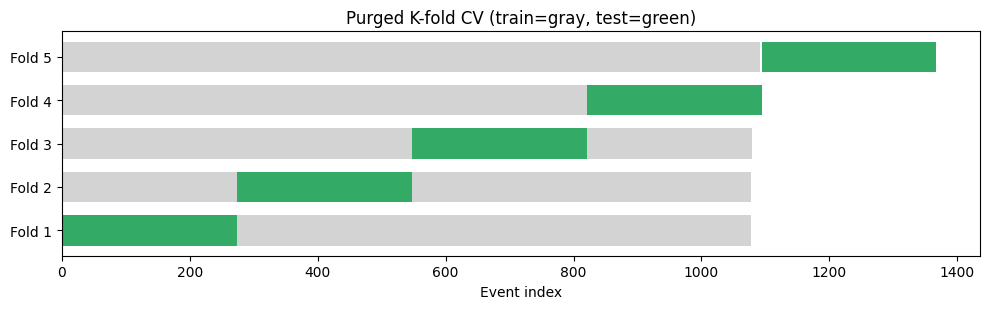

In [7]:
aligned_idx = features.index.intersection(labels.index)
X = features.loc[aligned_idx]
y = labels.loc[aligned_idx, "bin"].astype(int)
target_vol = labels.loc[aligned_idx, "target_vol"]
t1 = events.loc[aligned_idx, "t1"]

print(f"Aligned events: {len(X)}")
print(f"Label balance: {dict(y.value_counts().sort_index())}")

cv = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)

# Visualize folds (AFML figure 7.3 style)
fig, ax = plt.subplots(figsize=(10, 3.2))
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X)):
    ax.barh(fold_idx, len(train_idx), height=0.7, color="lightgray", left=0)
    test_left = test_idx[0]
    ax.barh(fold_idx, len(test_idx), height=0.7, color="#3a6", left=test_left)
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Event index")
ax.set_title("Purged K-fold CV (train=gray, test=green)")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "purged_kfold_visualization.png", dpi=120)
plt.show()

## 8. Model fits

Five models, same CV folds, same labels:

1. **Majority class** — sanity floor.
2. **SES** — exponential smoothing on the label series. Sanity check for short-horizon label autocorrelation.
3. **ARIMA** — fit on `frac_diff_close`, forecast forward, threshold by `±0.5σ` to map to `{-1, 0, +1}`.
4. **XGBoost** — `multi:softprob`, 3 classes, max_depth=4, n_estimators=300. The non-deep baseline that often beats LSTMs on tabular features.
5. **Refined LSTM** — `LSTM(32) → LSTM(16) → Dense(3, softmax)`, clipnorm=1.0, recurrent_dropout=0.1, categorical_crossentropy.

Sample weights = uniqueness weights from AFML Ch.4 (approximate version).

In [8]:
from src.models.baselines import MajorityClassClassifier, SESClassifier
from src.models.arima_model import ARIMAClassifier
from src.models.xgb_model import XGBTripleBarrier
from src.models.lstm_model import LSTMTripleBarrier

sw = uniqueness_weights(t1)
print(f"Mean uniqueness weight: {sw.mean():.3f} (uniform = 1.0)")
print(f"Min/max: {sw.min():.3f} / {sw.max():.3f}")

# ARIMA needs target_vol; add it as a column for that model only
X_with_vol = X.assign(target_vol=target_vol.values)

all_results = []
print("\nRunning Majority...")
all_results.append(run_cv("Majority", MajorityClassClassifier, X, y, cv, sample_weight=sw))
print("Running SES...")
all_results.append(run_cv("SES", SESClassifier, X, y, cv, sample_weight=sw, standardize=False))
print("Running ARIMA...")
all_results.append(run_cv("ARIMA", lambda: ARIMAClassifier(order=(1, 1, 1), threshold_k=0.5), X_with_vol, y, cv, sample_weight=sw, standardize=False))
print("Running XGBoost...")
all_results.append(run_cv("XGBoost", XGBTripleBarrier, X, y, cv, sample_weight=sw))
print("Running LSTM (this is slow — 5 folds × ~50 epochs)...")
all_results.append(run_cv("LSTM", lambda: LSTMTripleBarrier(sequence_length=60, n_features=X.shape[1], epochs=50, patience=15), X, y, cv, sample_weight=sw))

results = pd.concat(all_results, ignore_index=True)
results

Mean uniqueness weight: 1.000 (uniform = 1.0)
Min/max: 0.366 / 4.393

Running Majority...
Running SES...
Running ARIMA...


Running XGBoost...


Running LSTM (this is slow — 5 folds × ~50 epochs)...


I0000 00:00:1779332328.444316  127980 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779332334.847884  127980 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1779332370.539333  127980 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1779332381.016651  127980 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,model,fold,n_test,accuracy,binom_p_acc,n_acting,dir_acc_when_acting,binom_p_dir
0,Majority,0,274,0.3175,0.7307,0,NaN,NaN
1,Majority,1,274,0.3613,0.1789,274,0.3613,1.0000
2,Majority,2,273,0.3553,0.2390,273,0.3553,1.0000
3,Majority,3,273,0.3736,0.0897,273,0.3736,1.0000
4,Majority,4,273,0.3443,0.3717,0,NaN,NaN
5,SES,0,274,0.3175,0.7307,0,NaN,NaN
6,SES,1,274,0.3832,0.0469,0,NaN,NaN
7,SES,2,273,0.3846,0.0427,0,NaN,NaN
8,SES,3,273,0.4103,0.0047,0,NaN,NaN
9,SES,4,273,0.3443,0.3717,0,NaN,NaN


## 9. Comparison table & statistical significance

Each row of the per-fold table now carries `binom_p_acc` (against null = 1/3) and `binom_p_dir` (against null = 1/2 over predictions ≠ 0). A model "beats chance" only if the p-value column is consistently below 0.05.

Per-model summary (mean across folds):
   model  accuracy_mean  accuracy_std  binom_p_acc_mean  binom_p_acc_std  dir_acc_when_acting_mean  dir_acc_when_acting_std  binom_p_dir_mean  binom_p_dir_std  n_folds
   ARIMA         0.3680        0.0367            0.2393           0.3121                       NaN                      NaN               NaN              NaN        5
    LSTM         0.3972        0.0227            0.0468           0.0866                    0.3551                   0.0296            0.9993           0.0015        5
Majority         0.3504        0.0212            0.3220           0.2504                    0.3634                   0.0093            1.0000           0.0000        5
     SES         0.3680        0.0367            0.2393           0.3121                       NaN                      NaN               NaN              NaN        5
 XGBoost         0.3782        0.0236            0.1145           0.1354                    0.3602                   0.02

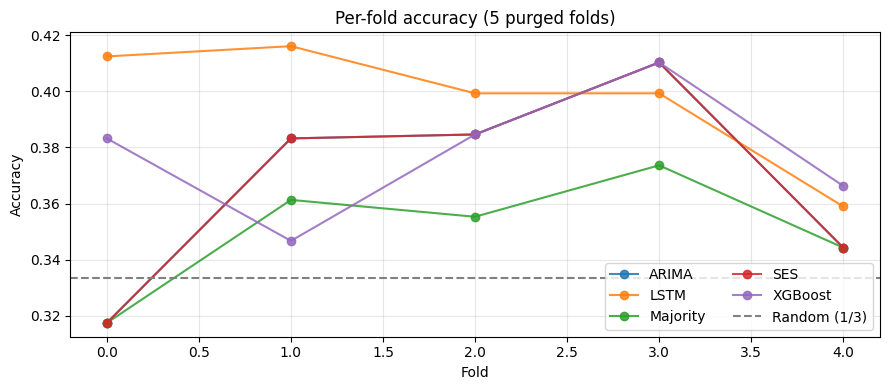

In [9]:
summary = summarize_results(results)
print("Per-model summary (mean across folds):")
print(summary.to_string(index=False))

results.to_csv(ROOT / "reports" / "tables" / "refined_model_comparison.csv", index=False)
summary.to_csv(ROOT / "reports" / "tables" / "refined_model_comparison_summary.csv", index=False)

# Per-fold accuracy chart
fig, ax = plt.subplots(figsize=(9, 4))
for model_name, grp in results.groupby("model"):
    ax.plot(grp["fold"], grp["accuracy"], "o-", label=model_name, alpha=0.85)
ax.axhline(1 / 3, ls="--", color="gray", label="Random (1/3)")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Per-fold accuracy (5 purged folds)")
ax.legend(loc="best", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "per_fold_accuracy.png", dpi=120)
plt.show()

## 10. Confusion matrices (last fold)

Sanity check that the models aren't degenerate (e.g. only predicting one class). A model that's collapsed to one class will show one column dense and the others empty.

In [10]:
from src.train import fit_predict_one_fold

last_fold = list(cv.split(X))[-1]
X_train_last, X_test_last = X.iloc[last_fold[0]], X.iloc[last_fold[1]]
X_train_last_v, X_test_last_v = X_with_vol.iloc[last_fold[0]], X_with_vol.iloc[last_fold[1]]
y_train_last, y_test_last = y.iloc[last_fold[0]], y.iloc[last_fold[1]]

print(f"Last fold: train={len(X_train_last)}, test={len(X_test_last)}\n")
for name, builder, Xtr, Xte, std in [
    ("Majority", MajorityClassClassifier, X_train_last, X_test_last, True),
    ("XGBoost", XGBTripleBarrier, X_train_last, X_test_last, True),
    ("ARIMA", lambda: ARIMAClassifier(order=(1, 1, 1), threshold_k=0.5), X_train_last_v, X_test_last_v, False),
]:
    y_pred, _ = fit_predict_one_fold(builder, Xtr, y_train_last, Xte, standardize=std)
    print(f"--- {name} ---")
    print(confusion_table(y_test_last.values, y_pred))
    print()

Last fold: train=1092, test=273

--- Majority ---
         pred_-1  pred_0  pred_1
true_-1        0      74       0
true_0         0      94       0
true_1         0     105       0



--- XGBoost ---
         pred_-1  pred_0  pred_1
true_-1       19      39      16
true_0        27      37      30
true_1        18      55      32



--- ARIMA ---
         pred_-1  pred_0  pred_1
true_-1        0      74       0
true_0         0      94       0
true_1         0     105       0



## 11. Discussion

What this notebook is *not*: a profit-generating trading system. With ~3,500 trading days of daily AAPL data, the upper bound on what any model can learn here is small, and even a model that beats chance in this setup hasn't been tested for transaction costs, slippage, regime change between training and live deployment, or any of the other things AFML Ch.11 covers.

What this notebook *is*: an honest evaluation of whether the original notebook's "the LSTM doesn't really work" finding survives a rebuild under the canonical financial-ML practices. Three outcomes are possible:

1. **LSTM still loses to SES/Majority.** The honest reading: even with proper labels, FFD features, and purged CV, daily-bar AAPL doesn't contain enough exploitable structure for a sequence model to find. This matches a body of literature on the difficulty of equity return forecasting.
2. **XGBoost beats LSTM.** Predicted by Jansen Ch.12 — tabular features + GBM usually wins on small datasets. The finding would be "the LSTM-shaped model was the wrong choice for this feature set," not "LSTMs are bad."
3. **LSTM is competitive.** The labeling/CV fixes did the work the original was missing. This is the least likely outcome on this dataset but worth checking.

In all three cases, the binomial p-values matter more than the point estimates. With ~500 events per test fold, even a 55% accuracy can be p > 0.05 — meaning we'd say "promising direction" not "model works."